In [2]:
import pandas as pd
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
data

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_VEGRES1,_FRUTSU1,_VEGESU1,_FRTLT1A,_VEGLT1A,_FRT16A,_VEG23A,_FRUITE1,_VEGETE1,CVD_LABEL
0,1.0,1.0,b'01192021',b'01',b'19',b'2021',1100.0,b'2021000001',2.021000e+09,1.0,...,1.0,100.0,214.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
1,1.0,1.0,b'01212021',b'01',b'21',b'2021',1100.0,b'2021000002',2.021000e+09,1.0,...,1.0,100.0,128.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,CHD Only
2,1.0,1.0,b'01212021',b'01',b'21',b'2021',1100.0,b'2021000003',2.021000e+09,1.0,...,1.0,100.0,71.0,1.0,2.0,1.0,1.0,5.397605e-79,5.397605e-79,CHD Only
3,1.0,1.0,b'01172021',b'01',b'17',b'2021',1100.0,b'2021000004',2.021000e+09,1.0,...,1.0,114.0,165.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
4,1.0,1.0,b'01152021',b'01',b'15',b'2021',1100.0,b'2021000005',2.021000e+09,1.0,...,1.0,100.0,258.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,MI + Stroke
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,78.0,12.0,b'01062022',b'01',b'06',b'2022',1100.0,b'2021001381',2.021001e+09,NaN,...,1.0,157.0,393.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
438689,78.0,12.0,b'01122022',b'01',b'12',b'2022',1100.0,b'2021001382',2.021001e+09,NaN,...,1.0,200.0,157.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
438690,78.0,12.0,b'12212021',b'12',b'21',b'2021',1100.0,b'2021001383',2.021001e+09,NaN,...,1.0,200.0,143.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
438691,78.0,12.0,b'01112022',b'01',b'11',b'2022',1100.0,b'2021001384',2.021001e+09,NaN,...,1.0,100.0,156.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt


In [3]:
data.isnull().sum()

_STATE       0
FMONTH       0
IDATE        0
IMONTH       0
IDAY         0
            ..
_FRT16A      0
_VEG23A      0
_FRUITE1     0
_VEGETE1     0
CVD_LABEL    0
Length: 304, dtype: int64

In [4]:
data['CVD_LABEL'].value_counts()

CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

In [5]:
miss = data.isnull().mean().sort_values(ascending=False) * 100
miss

HAVECFS      100.000000
WORKCFS      100.000000
TOLDCFS      100.000000
COLGHOUS      99.993162
COLGSEX       99.993162
                ...    
_TOTINDA       0.000000
_HCVU652       0.000000
_HLTHPLN       0.000000
_MENT14D       0.000000
CVD_LABEL      0.000000
Length: 304, dtype: float64

In [6]:
high = (miss >= 25).sum()
high

165

In [7]:
# Hapus kolom dengan missing value >= 50%
threshold = 25
cols_to_drop = miss[miss > threshold].index
data1 = data.drop(columns=cols_to_drop)

print(f"Kolom yang dihapus ({len(cols_to_drop)}): {list(cols_to_drop)}")
print(f"Shape sebelum: {data.shape}")
print(f"Shape sesudah: {data1.shape}")

Kolom yang dihapus (165): ['HAVECFS', 'WORKCFS', 'TOLDCFS', 'COLGHOUS', 'COLGSEX', 'SIGMTES1', 'MEDSHEPB', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'VCLNTES1', 'SDNATES1', 'BLDSTFIT', 'CSRVCTL2', 'LASTSIG4', 'PCSTALK', 'PCPSARS2', 'PSATIME1', 'STOLTEST', 'CCLGHOUS', 'CDHELP', 'STOOLDN1', 'VIRCOLO1', 'SMALSTOL', 'PSATEST1', 'HPVADSHT', 'CSRVINST', 'LOADULK2', 'CDDISCUS', 'CDSOCIAL', 'CDASSIST', 'CDHOUSE', 'CSRVCLIN', 'CSRVDEIN', 'CSRVINSR', 'CSRVRTRN', 'CSRVSUM', 'CSRVDOC1', 'COLNTES1', 'CRVCLPAP', 'CRVCLHPV', 'CRVCLCNC', 'COLNSIGM', 'CASTHNO2', 'CSRVTRT3', 'HOWLONG', 'COLNCNCR', 'HADSIGM4', 'CSRVPAIN', 'HADHYST2', 'CERVSCRN', 'HADMAM', 'CNCRTYP1', 'CNCRAGE', 'CNCRDIFF', 'HAVEHEPB', 'TOLDHEPC', 'LCSNUMCG', 'LCSLAST', 'GUNLOAD', 'LCSFIRST', 'HPVADVC4', 'RSNMRJN2', 'USEMRJN3', 'SHINGLE2', 'TETANUS1', 'FEETCHK', 'DIABEDU', 'DIABEYE', 'EYEEXAM1', 'CHKHEMO3', 'DOCTDIAB', 'FEETCHK3', 'INSULIN1', 'BLDSUGAR', 'STOPSMK2', 'LCSCTSCN', 'FIREARM5', 'NUMPHON3', 'CIMEMLOS', 'CRGVALZD', 'DRADVISE', 'WTCHSA

In [8]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Columns: 139 entries, _STATE to CVD_LABEL
dtypes: float64(133), object(6)
memory usage: 465.2+ MB


In [9]:
# Cara 1 - Print list kolom yang dihapus
cols_to_drop = miss[miss >= 25].index
print(f"Kolom yang dihapus ({len(cols_to_drop)}):")
print(list(cols_to_drop))

Kolom yang dihapus (165):
['HAVECFS', 'WORKCFS', 'TOLDCFS', 'COLGHOUS', 'COLGSEX', 'SIGMTES1', 'MEDSHEPB', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'VCLNTES1', 'SDNATES1', 'BLDSTFIT', 'CSRVCTL2', 'LASTSIG4', 'PCSTALK', 'PCPSARS2', 'PSATIME1', 'STOLTEST', 'CCLGHOUS', 'CDHELP', 'STOOLDN1', 'VIRCOLO1', 'SMALSTOL', 'PSATEST1', 'HPVADSHT', 'CSRVINST', 'LOADULK2', 'CDDISCUS', 'CDSOCIAL', 'CDASSIST', 'CDHOUSE', 'CSRVCLIN', 'CSRVDEIN', 'CSRVINSR', 'CSRVRTRN', 'CSRVSUM', 'CSRVDOC1', 'COLNTES1', 'CRVCLPAP', 'CRVCLHPV', 'CRVCLCNC', 'COLNSIGM', 'CASTHNO2', 'CSRVTRT3', 'HOWLONG', 'COLNCNCR', 'HADSIGM4', 'CSRVPAIN', 'HADHYST2', 'CERVSCRN', 'HADMAM', 'CNCRTYP1', 'CNCRAGE', 'CNCRDIFF', 'HAVEHEPB', 'TOLDHEPC', 'LCSNUMCG', 'LCSLAST', 'GUNLOAD', 'LCSFIRST', 'HPVADVC4', 'RSNMRJN2', 'USEMRJN3', 'SHINGLE2', 'TETANUS1', 'FEETCHK', 'DIABEDU', 'DIABEYE', 'EYEEXAM1', 'CHKHEMO3', 'DOCTDIAB', 'FEETCHK3', 'INSULIN1', 'BLDSUGAR', 'STOPSMK2', 'LCSCTSCN', 'FIREARM5', 'NUMPHON3', 'CIMEMLOS', 'CRGVALZD', 'DRADVISE', 'WTCHSA

In [10]:
data1 = data1.drop(columns=['IDATE', 'IMONTH', 'IDAY', 'IYEAR','_STATE','FMONTH','DISPCODE','SEQNO','_PSU'])

In [11]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data1.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data1[col].value_counts(dropna=False))


Kolom: SEXVAR
SEXVAR
2.0    234883
1.0    203810
Name: count, dtype: int64

Kolom: GENHLTH
GENHLTH
2.0    149112
3.0    137938
1.0     77741
4.0     54736
5.0     18005
7.0       788
9.0       369
NaN         4
Name: count, dtype: int64

Kolom: PHYSHLTH
PHYSHLTH
88.0    287796
30.0     29732
2.0      22220
1.0      17063
3.0      12868
5.0      11642
10.0      8595
77.0      7898
15.0      7623
4.0       6821
7.0       6695
20.0      4670
14.0      3994
6.0       1901
25.0      1866
99.0      1593
8.0       1254
21.0       927
12.0       813
28.0       671
9.0        302
29.0       279
18.0       253
16.0       222
17.0       158
27.0       155
13.0       126
22.0       120
11.0       119
26.0       108
24.0        98
23.0        65
19.0        43
NaN          3
Name: count, dtype: int64

Kolom: MENTHLTH
MENTHLTH
88.0    271161
30.0     24953
2.0      22717
5.0      19130
3.0      14567
10.0     14554
15.0     13475
1.0      13091
20.0      7993
7.0       7428
4.0       7419
77.0     

In [12]:
# Cara 4 - Dalam bentuk DataFrame (paling mudah dibaca)
pd.DataFrame({
    'Kolom': data1.columns,
    'Tipe Data': data1.dtypes.values,
    'Missing (%)': (data1.isnull().mean() * 100).round(2).values
})

,Kolom,Tipe Data,Missing (%)
0,SEXVAR,float64,0.0
1,GENHLTH,float64,0.0
2,PHYSHLTH,float64,0.0
3,MENTHLTH,float64,0.0
4,PRIMINSR,float64,0.0
...,...,...,...
125,_FRT16A,float64,0.0
126,_VEG23A,float64,0.0
127,_FRUITE1,float64,0.0
128,_VEGETE1,float64,0.0


In [13]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 2,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 2,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 2,  # Level 2 → 2 kondisi
    'All Three'         : 3,  # Level 3 → 3 kondisi
}

data1['CVD_SEVERITY'] = data1['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data1['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     32861
2     11866
3      2114
Name: count, dtype: int64

Total : 438,693


In [14]:
data1 = data1.drop(columns=['_VEGRES1','_FRTRES1','_MISVEG1','_MISFRT1','CVD_LABEL'])
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Columns: 126 entries, SEXVAR to CVD_SEVERITY
dtypes: float64(125), int64(1)
memory usage: 421.7 MB


In [15]:
# Cek null semua kolom
null_summary = pd.DataFrame({
    'null_count': data1.isnull().sum(),
    'null_percent': (data1.isnull().sum() / len(data1) * 100).round(2)
}).sort_values('null_percent', ascending=False)

print(null_summary[null_summary['null_count'] > 0])

          null_count  null_percent
CHOLMED3       61571         14.04
_RFCHOL3       61151         13.94
TOLDHI3        60836         13.87
_VEGESU1       60127         13.71
_FRUTSU1       51087         11.65
...              ...           ...
PHYSHLTH           3          0.00
HAVARTH5           3          0.00
EDUCA              5          0.00
RENTHOM1           8          0.00
GENHLTH            4          0.00

[75 rows x 2 columns]


In [16]:
data_new = data1.dropna()
print(f"Sebelum : {len(data1)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data1) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 289586 baris
Terhapus: 149107 baris


In [17]:
# Pastikan semua kolom ini tidak ada
forbidden = ['_MICHD', 'CVDSTRK3', 'CVDCRHD4', 'CVDINFR4']
data_new = data_new.drop(columns=forbidden)
for col in forbidden:
    if col in data_new.columns:
        print(f"⚠️  MASIH ADA: {col}")
    else:
        print(f"✅ Sudah dihapus: {col}")

✅ Sudah dihapus: _MICHD
✅ Sudah dihapus: CVDSTRK3
✅ Sudah dihapus: CVDCRHD4
✅ Sudah dihapus: CVDINFR4


In [18]:
# ============================================================
# SUBSAMPLE — ambil N baris random dari seluruh data
# ============================================================

SAMPLE_SIZE = 50_000   # ← ganti sesuai kebutuhan

data_sampled = data_new.sample(n=SAMPLE_SIZE, random_state=42)

print("Distribusi setelah sampling:")
print(data_sampled['CVD_SEVERITY'].value_counts().sort_index())

# ── Split seperti biasa dari data yang sudah disubsample ────
X = data_sampled.drop(columns=['CVD_SEVERITY'])
y = data_sampled['CVD_SEVERITY']


Distribusi setelah sampling:
CVD_SEVERITY
0    44080
1     4092
2     1567
3      261
Name: count, dtype: int64


In [19]:
# X = data_new.drop(columns=['CVD_SEVERITY'])
# y = data_new['CVD_SEVERITY']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
X.shape

(50000, 121)

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

# ── 1. Model dengan threshold lebih agresif ──────────────────────────────
model = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=4,
)

# ── 2. Perkuat bobot kelas minoritas secara manual ───────────────────────
# Daripada 'balanced', kasih extra weight ke kelas 2 & 3
custom_weights = {0: 1, 1: 10, 2: 25, 3: 150}  # ✅ sesuaikan dengan distribusi
sample_weights = np.array([custom_weights[label] for label in y_train])

model.fit(X_train, y_train, sample_weight=sample_weights)

# ── 3. Prediksi dengan custom threshold ──────────────────────────────────
y_prob = model.predict_proba(X_test)  # shape: (n_samples, 4)

# Turunkan threshold untuk kelas minoritas (default 0.5 → lebih rendah)
thresholds = [0.5, 0.3, 0.2, 0.15]   # ✅ kelas 1,2,3 lebih mudah diprediksi

y_pred_custom = np.array([
    np.argmax([
        prob[0] * (1 / thresholds[0]),
        prob[1] * (1 / thresholds[1]),
        prob[2] * (1 / thresholds[2]),
        prob[3] * (1 / thresholds[3]),
    ])
    for prob in y_prob
])

# ── 4. Evaluasi ───────────────────────────────────────────────────────────
print("=" * 55)
print("CLASSIFICATION REPORT (Custom Threshold)")
print("=" * 55)
print(classification_report(
    y_test, y_pred_custom,
    target_names=['Sehat', 'Ringan', 'Sedang', 'Berat']
))

print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'):.4f}")
print(f"Recall (macro)  : {recall_score(y_test, y_pred_custom, average='macro'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_custom, average='weighted'):.4f}")

print("\nRecall per Kelas:")
recalls = recall_score(y_test, y_pred_custom, average=None)
for name, r in zip(['Sehat', 'Ringan', 'Sedang', 'Berat'], recalls):
    bar = '█' * int(r * 20)
    print(f"  {name:<7}: {bar:<20} {r:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

CLASSIFICATION REPORT (Custom Threshold)
              precision    recall  f1-score   support

       Sehat       0.94      0.82      0.88      8816
      Ringan       0.19      0.38      0.25       819
      Sedang       0.13      0.27      0.18       313
       Berat       0.00      0.00      0.00        52

    accuracy                           0.76     10000
   macro avg       0.32      0.37      0.33     10000
weighted avg       0.85      0.76      0.80     10000

AUC-ROC  : 0.8065
Recall (macro)  : 0.3677
Recall (weighted): 0.7638

Recall per Kelas:
  Sehat  : ████████████████     0.8215
  Ringan : ███████              0.3810
  Sedang : █████                0.2684
  Berat  :                      0.0000

Confusion Matrix:
[[7242 1189  381    4]
 [ 355  312  152    0]
 [  93  135   84    1]
 [  14   25   13    0]]


## Feature Selection

Top 20 Feature Importance:
     feature  importance
0   CHOLMED3    0.068358
1   _RFHYPE6    0.052559
2    GENHLTH    0.030529
3   DIFFWALK    0.024536
4   _RFCHOL3    0.024215
5    EMPLOY1    0.023762
6       _SEX    0.016985
7   _PHYS14D    0.016497
8   _CURECI1    0.014146
9   DIABETE4    0.013661
10    _AGE80    0.011953
11  _MENT14D    0.011743
12  CHCCOPD3    0.010931
13  CHCKDNY2    0.010904
14  VETERAN3    0.010723
15  _RFSMOK3    0.010651
16  _SMOKER3    0.009916
17    DECIDE    0.009874
18  CHCSCNCR    0.009842
19  POTATOE1    0.009814


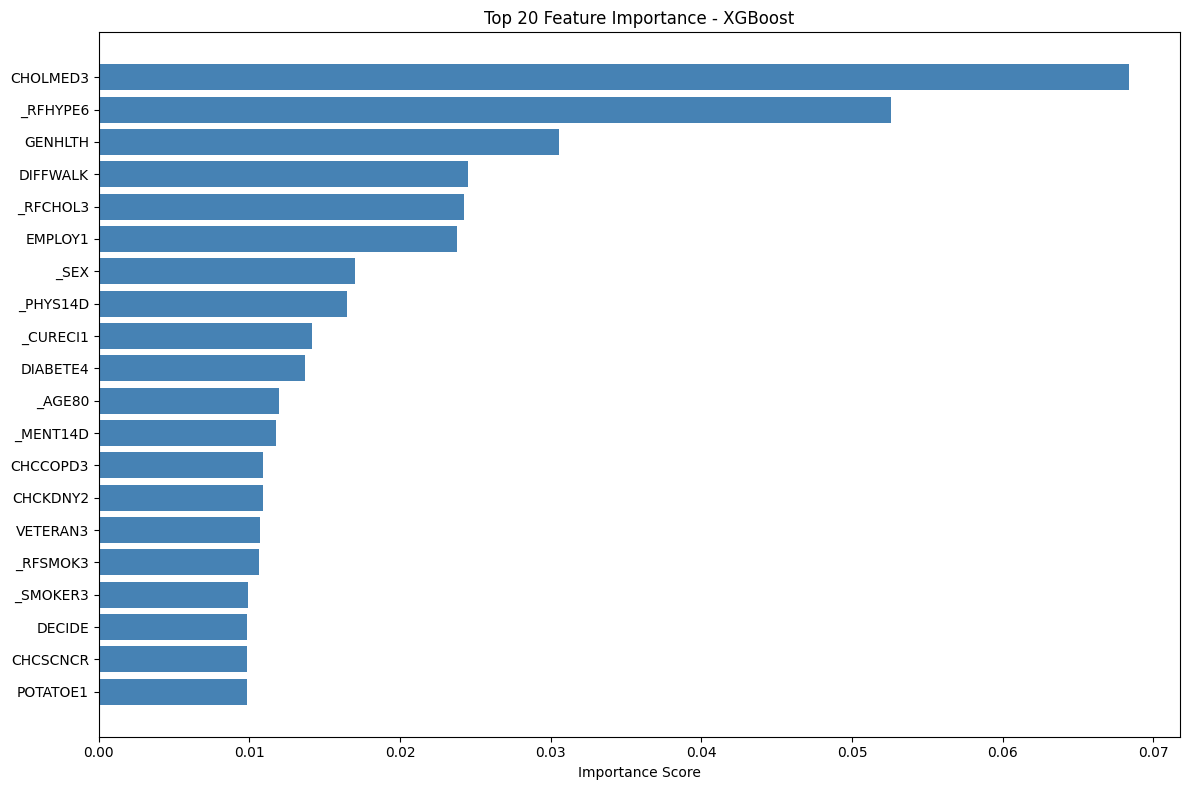

In [28]:
import matplotlib.pyplot as plt
# ── 1. Feature Importance dari model XGBoost yang sudah ditraining ──
importances = model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Feature Importance:")
print(feat_imp_df.head(20))

# %%
# ── 2. Plot Feature Importance ──
plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(
    feat_imp_df['feature'][:top_n][::-1],
    feat_imp_df['importance'][:top_n][::-1],
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
from tqdm import tqdm
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import classification_report, roc_auc_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd

CLASS_NAMES = ['Sehat', 'Ringan', 'Sedang', 'Berat']
N_CLASSES   = 4

desils = [1, 2, 3, 4, 5, 6, 7, 8, 9]

resamplers = {
    'sample_weight' : None,           # ✅ ganti dari scale_pos_weight
    'SMOTE'         : SMOTE(random_state=42),
    'ADASYN'        : ADASYN(random_state=42),
    'SMOTETomek'    : SMOTETomek(random_state=42),
    'SMOTEENN'      : SMOTEENN(random_state=42),
}

results_all = {}
N_total = len(feat_imp_df)

outer_bar = tqdm(desils, desc="Desil", position=0)

for D in outer_bar:
    N_FEATURES       = int(np.ceil(N_total * D / 10))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_d = X_train[selected_features]
    X_test_d  = X_test[selected_features]
    outer_bar.set_postfix({'fitur': N_FEATURES})

    inner_bar = tqdm(resamplers.items(), desc=f"  Resampler (D={D})", position=1, leave=False)

    for resampler_name, sampler in inner_bar:
        inner_bar.set_postfix({'method': resampler_name})

        # ── Resampling ──────────────────────────────────────────────────────
        if sampler is None:
            X_res, y_res = X_train_d, y_train
            # ✅ balanced sample_weight untuk semua kelas
            sw = compute_sample_weight(class_weight='balanced', y=y_train)
        else:
            X_res, y_res = sampler.fit_resample(X_train_d, y_train)
            sw = None   # setelah resampling distribusi sudah seimbang

        # ── Model ───────────────────────────────────────────────────────────
        xgb_model_d = XGBClassifier(
            n_estimators     = 300,
            max_depth        = 6,
            learning_rate    = 0.05,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            objective        = 'multi:softprob',  # ✅ multi-class
            num_class        = N_CLASSES,          # ✅ jumlah kelas
            eval_metric      = 'mlogloss',         # ✅ ganti dari logloss
            random_state     = 42,
            n_jobs           = -1
        )
        xgb_model_d.fit(X_res, y_res, sample_weight=sw)  # ✅ sw bisa None

        # ── Prediksi ────────────────────────────────────────────────────────
        y_pred = xgb_model_d.predict(X_test_d)
        y_prob = xgb_model_d.predict_proba(X_test_d)      # ✅ semua kolom (n, 4)

        report = classification_report(
            y_test, y_pred,
            target_names=CLASS_NAMES,
            output_dict=True
        )

        # ── Recall per kelas ────────────────────────────────────────────────
        recalls = recall_score(y_test, y_pred, average=None)  # [r0, r1, r2, r3]

        key = f'D{D}_{resampler_name}'
        results_all[key] = {
            'Desil'          : D,
            'N Fitur'        : N_FEATURES,
            'Resampler'      : resampler_name,
            # ✅ Recall per kelas
            'Recall Sehat'   : recalls[0],
            'Recall Ringan'  : recalls[1],
            'Recall Sedang'  : recalls[2],
            'Recall Berat'   : recalls[3],
            'Recall Macro'   : report['macro avg']['recall'],
            # Metrik lain
            'F1 Macro'       : report['macro avg']['f1-score'],
            'F1 Weighted'    : report['weighted avg']['f1-score'],
            'Accuracy'       : report['accuracy'],
            # ✅ AUC multi-class ovr weighted
            'AUC'            : roc_auc_score(
                                   y_test, y_prob,
                                   multi_class='ovr',
                                   average='weighted'
                               )
        }

# ── Tabel hasil ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
results_df[['Desil', 'N Fitur']] = results_df[['Desil', 'N Fitur']].astype(int)

print("\n── Perbandingan Semua Kombinasi (sort by Recall Macro) ──")
print(results_df.sort_values('Recall Macro', ascending=False).to_string())

# ── Best berdasarkan Recall Macro ─────────────────────────────────────────────
best = results_df.sort_values('Recall Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik (Recall Macro tertinggi):")
print(f"   Desil         : {best['Desil']} ({int(best['Desil'])*10}% fitur teratas)")
print(f"   N Fitur       : {best['N Fitur']}")
print(f"   Resampler     : {best['Resampler']}")
print(f"   Recall Macro  : {best['Recall Macro']:.4f}")
print(f"   Recall Berat  : {best['Recall Berat']:.4f}")   # kelas paling kritis
print(f"   AUC           : {best['AUC']:.4f}")

Desil: 100%|██████████| 9/9 [09:36<00:00, 64.07s/it, fitur=109]


── Perbandingan Semua Kombinasi (sort by Recall Macro) ──
                  Desil  N Fitur      Resampler Recall Sehat Recall Ringan Recall Sedang Recall Berat Recall Macro  F1 Macro F1 Weighted Accuracy       AUC
D3_sample_weight      3       37  sample_weight      0.76225      0.421245      0.376997     0.076923     0.409354  0.337661    0.774404   0.7187  0.825177
D1_sample_weight      1       13  sample_weight     0.724705      0.391941      0.361022     0.096154     0.393456   0.31158     0.75253   0.6828  0.818816
D4_sample_weight      4       49  sample_weight     0.774841      0.424908      0.357827          0.0     0.389394  0.324945    0.780192   0.7291   0.82768
D7_sample_weight      7       85  sample_weight     0.788566      0.459096      0.309904          0.0     0.389392  0.330817    0.788465   0.7425  0.827445
D2_sample_weight      2       25  sample_weight     0.744215      0.417582      0.354633     0.038462     0.388723  0.316634     0.76464   0.7016  0.826588
D5_sa

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
# ── Konfigurasi 2 skenario terbaik ──────────────────────────
scenarios = {
    'D3_sample_weight': {
        'desil'     : 3,
        'resampler' : None,
    },
    'D1_sample_weight': {
        'desil'     : 1,
        'resampler' : None,
    },
    'D1_SMOTEENN': {
        'desil'     : 1,
        'resampler' : SMOTEENN(random_state=42),
    },
    'D2_SMOTEENN': {
        'desil'     : 2,
        'resampler' : SMOTEENN(random_state=42),
    },
}
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob',      # ← ganti dari binary
        eval_metric='mlogloss',          # ← ganti dari logloss
        num_class=4,                     # ← sesuaikan jumlah kelas
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='multiclass',          # ← ganti
        num_class=4,                     # ← sesuaikan
        metric='multi_logloss',          # ← ganti
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        loss_function='MultiClass',      # ← ganti dari Logloss
        eval_metric='Accuracy',          # ← ganti
        random_state=42, verbose=0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=6,
        class_weight='balanced',         # ← tambah untuk imbalance
        random_state=42, n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, max_depth=6,
        class_weight='balanced',         # ← tambah untuk imbalance
        random_state=42, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=42                  # ← otomatis support multiclass
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',       # ← ganti dari default ovr
        solver='lbfgs',                  # ← solver terbaik untuk multinomial
        class_weight='balanced',         # ← tambah untuk imbalance
        random_state=42, n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',              # ← tambah, lebih baik untuk multiclass
        n_jobs=-1
    ),
}


Skenario : D3_sample_weight | 37 fitur


D3_sample_weight:   0%|          | 0/8 [00:00<?, ?it/s]/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"


Skenario : D1_sample_weight | 13 fitur


D1_sample_weight:  25%|██▌       | 2/8 [00:08<00:26,  4.46s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz


Skenario : D1_SMOTEENN | 13 fitur


D1_SMOTEENN:  75%|███████▌  | 6/8 [05:59<03:54, 117.46s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D1_SMOTEENN: 100%|██████████| 8/8 [06:09<00:00, 46.24s/it] 



Skenario : D2_SMOTEENN | 25 fitur


D2_SMOTEENN:  75%|███████▌  | 6/8 [14:16<09:30, 285.44s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D2_SMOTEENN: 100%|██████████| 8/8 [14:30<00:00, 108.78s/it]



── Perbandingan Semua Skenario × Model (sort by Recall Macro) ──
                                             Skenario               Model Recall None Recall Single Recall Double Recall All Three Prec None Prec Single Prec Double Prec All Three   F1 None F1 Single F1 Double F1 All Three  F1 Macro F1 Weighted Recall Macro Balanced Acc Accuracy AUC Macro OvR
D3_sample_weight_ExtraTrees          D3_sample_weight          ExtraTrees    0.755785      0.208791      0.271565         0.538462  0.954721    0.139592    0.101675       0.029167  0.843685  0.167319  0.147955     0.055336  0.303574    0.762415     0.443651     0.443651   0.6947      0.801874
D1_sample_weight_LogisticRegression  D1_sample_weight  LogisticRegression    0.712908      0.290598      0.268371              0.5  0.962039    0.135458    0.103704       0.028889  0.818946  0.184783  0.149599     0.054622  0.301987    0.742083     0.442969     0.442969   0.6633      0.792894
D3_sample_weight_RandomForest        D3_sample_weigh

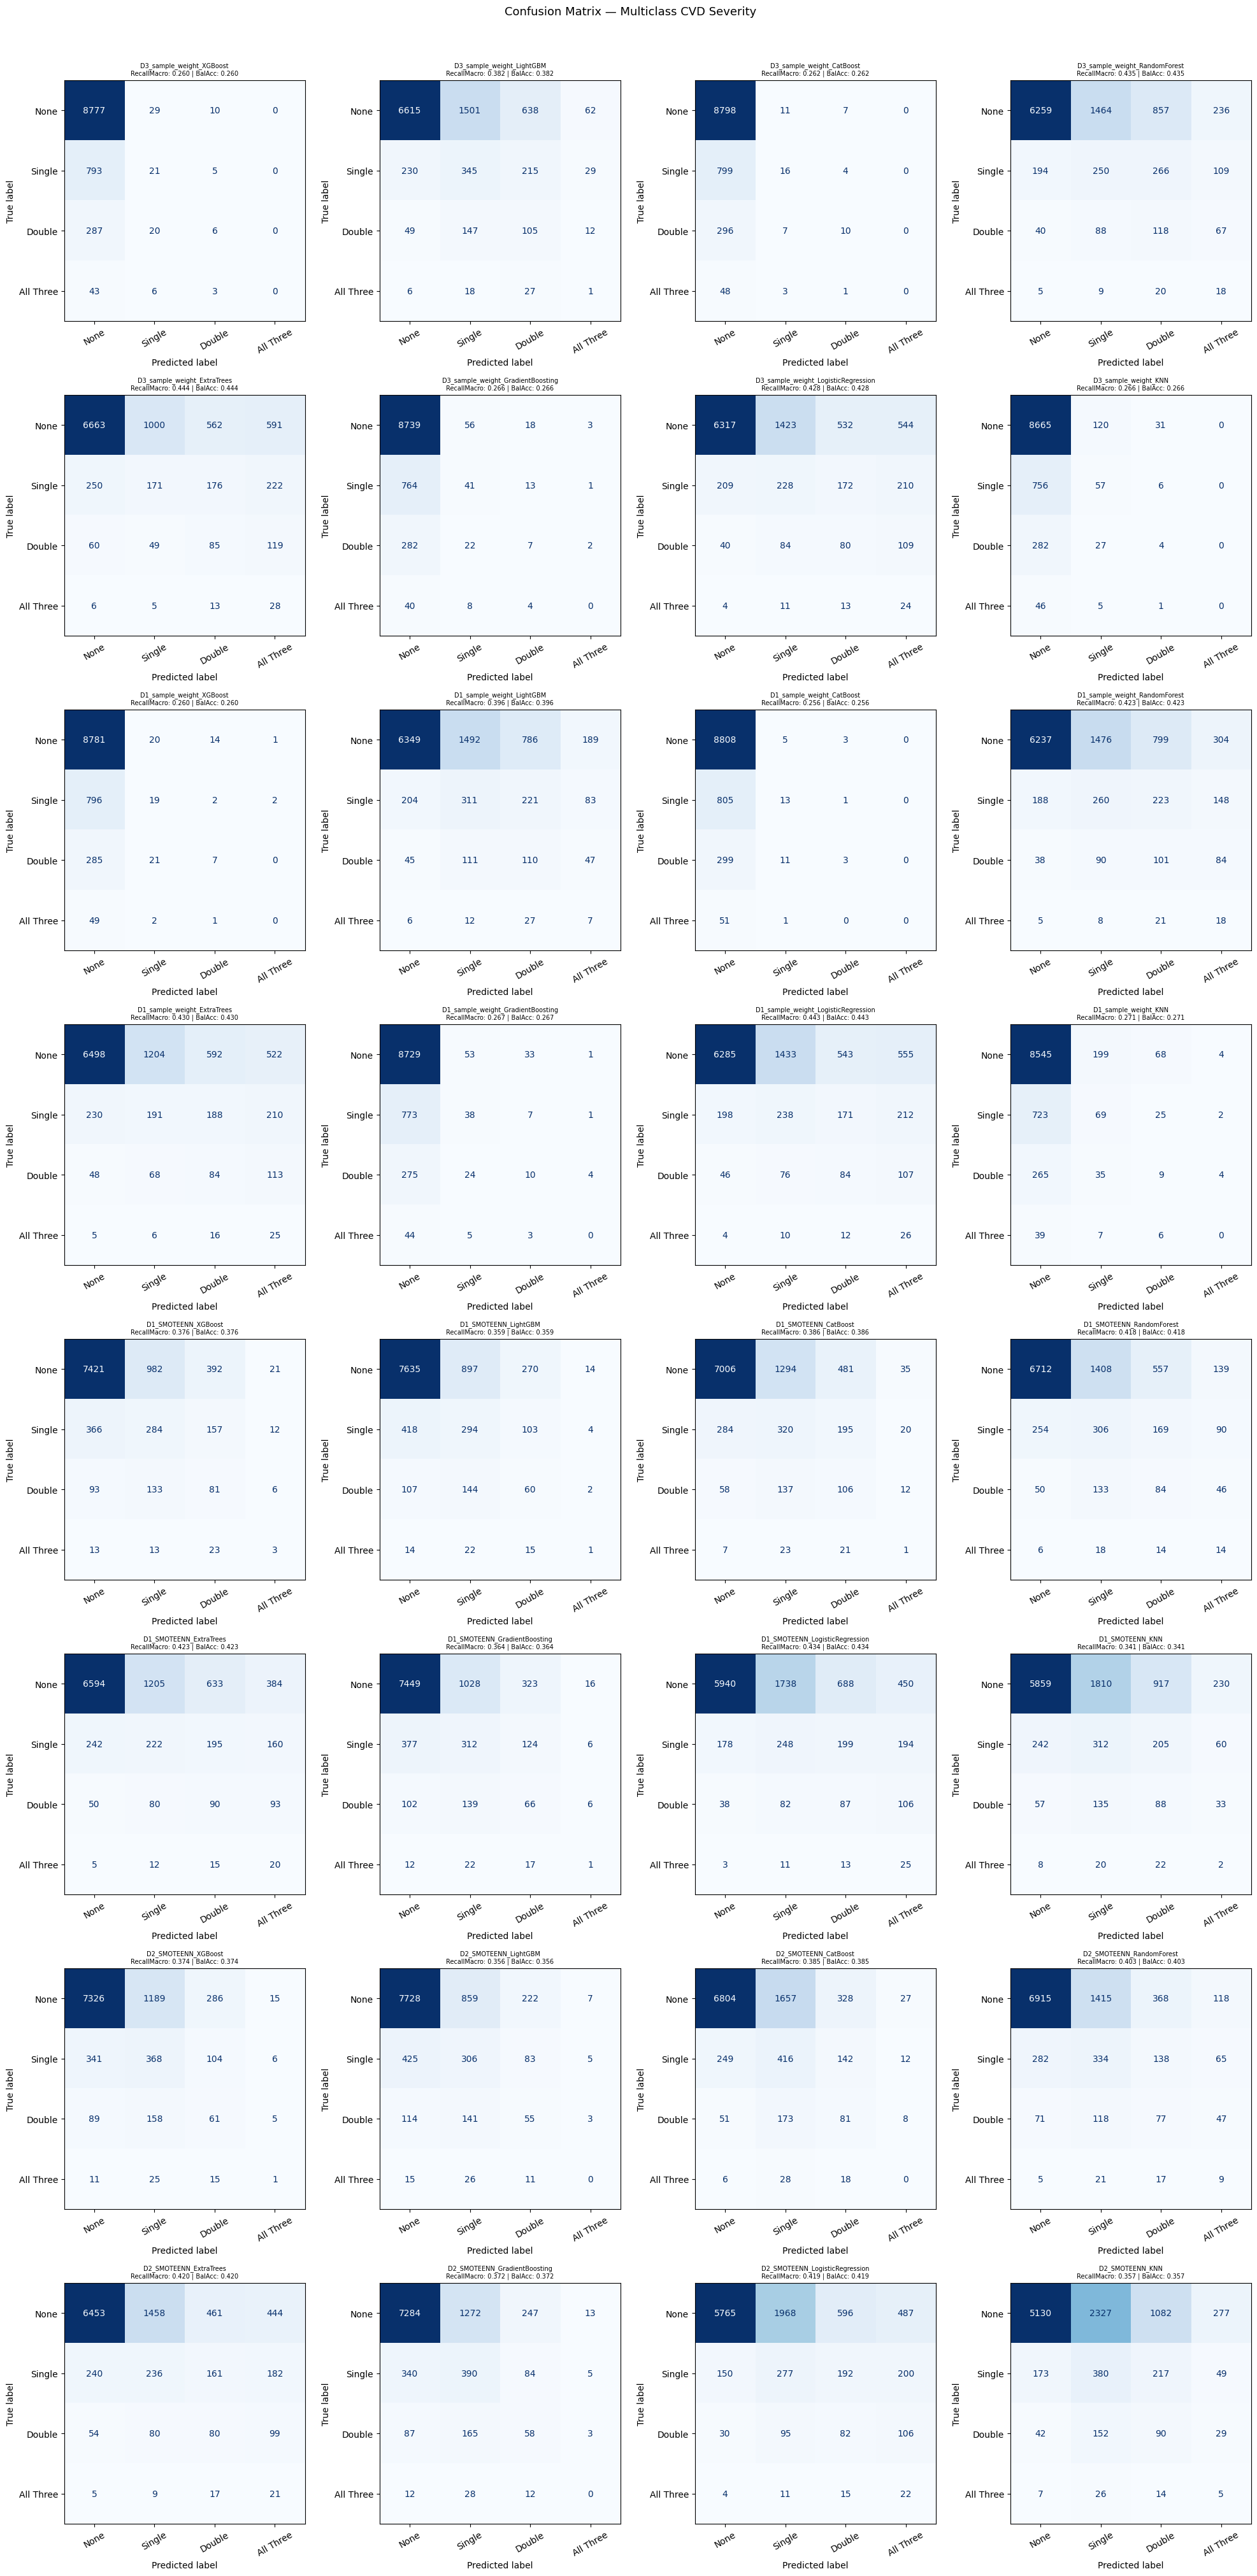

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Label kelas
CLASS_NAMES = ['None', 'Single', 'Double', 'All Three']  # sesuaikan urutanmu
N_CLASSES   = len(CLASS_NAMES)

# ── Loop skenario × model ────────────────────────────────────
results_all   = {}
conf_matrices = {}

for sc_name, sc_cfg in scenarios.items():
    N_FEATURES        = int(np.ceil(N_total * sc_cfg['desil'] / 10))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_sc = X_train[selected_features]
    X_test_sc  = X_test[selected_features]

    if sc_cfg['resampler'] is None:
        X_res, y_res = X_train_sc, y_train
    else:
        X_res, y_res = sc_cfg['resampler'].fit_resample(X_train_sc, y_train)

    print(f"\n{'='*55}")
    print(f"Skenario : {sc_name} | {N_FEATURES} fitur")
    print(f"{'='*55}")

    for model_name, clf in tqdm(models.items(), desc=sc_name):
        # ── Multiclass class_weight (hapus scale_pos_weight) ──
        if hasattr(clf, 'class_weight'):
            clf.set_params(class_weight='balanced')

        clf.fit(X_res, y_res)

        y_pred = clf.predict(X_test_sc)
        y_prob = clf.predict_proba(X_test_sc)          # shape (n, 4)
        report = classification_report(
            y_test, y_pred,
            target_names=CLASS_NAMES,
            output_dict=True
        )

        # ── AUC multiclass (OvR) ──────────────────────────────
        try:
            auc = roc_auc_score(
                y_test, y_prob,
                multi_class='ovr',
                average='macro'
            )
        except Exception:
            auc = np.nan

        key = f"{sc_name}_{model_name}"
        results_all[key] = {
            'Skenario'         : sc_name,
            'Model'            : model_name,

            # Recall per kelas ← fokus utama
            'Recall None'      : report['None']['recall'],
            'Recall Single'    : report['Single']['recall'],
            'Recall Double'    : report['Double']['recall'],
            'Recall All Three' : report['All Three']['recall'],

            # Precision per kelas
            'Prec None'        : report['None']['precision'],
            'Prec Single'      : report['Single']['precision'],
            'Prec Double'      : report['Double']['precision'],
            'Prec All Three'   : report['All Three']['precision'],

            # F1 per kelas
            'F1 None'          : report['None']['f1-score'],
            'F1 Single'        : report['Single']['f1-score'],
            'F1 Double'        : report['Double']['f1-score'],
            'F1 All Three'     : report['All Three']['f1-score'],

            # Agregat
            'F1 Macro'         : report['macro avg']['f1-score'],
            'F1 Weighted'      : report['weighted avg']['f1-score'],
            'Recall Macro'     : report['macro avg']['recall'],
            'Balanced Acc'     : balanced_accuracy_score(y_test, y_pred),
            'Accuracy'         : report['accuracy'],
            'AUC Macro OvR'    : auc,
        }
        conf_matrices[key] = confusion_matrix(y_test, y_pred)

# ── Tabel hasil ──────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)

# Sort by Recall Macro (semua kelas seimbang)
results_sorted = results_df.sort_values('Recall Macro', ascending=False)

print("\n── Perbandingan Semua Skenario × Model (sort by Recall Macro) ──")
print(results_sorted.to_string())

# ── Best model ───────────────────────────────────────────────
best = results_sorted.iloc[0]
print(f"\n✅ Terbaik : {best.name}")
print(f"   Skenario      : {best['Skenario']}")
print(f"   Model         : {best['Model']}")
print(f"   Recall None   : {best['Recall None']}")
print(f"   Recall Single : {best['Recall Single']}")
print(f"   Recall Double : {best['Recall Double']}")
print(f"   Recall AllThree: {best['Recall All Three']}")
print(f"   Recall Macro  : {best['Recall Macro']}")
print(f"   Balanced Acc  : {best['Balanced Acc']}")
print(f"   AUC Macro OvR : {best['AUC Macro OvR']}")

# ── Confusion Matrix ──────────────────────────────────────────
n_total = len(conf_matrices)
ncols   = 4
nrows   = int(np.ceil(n_total / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
axes = axes.flatten()

for i, (key, cm) in enumerate(conf_matrices.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        f"{key}\n"
        f"RecallMacro: {results_all[key]['Recall Macro']:.3f} | "
        f"BalAcc: {results_all[key]['Balanced Acc']:.3f}",
        fontsize=7
    )
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix — Multiclass CVD Severity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()